In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [41]:
df=pd.read_csv('../datasets/customer_insurance_gridsearch_training.csv')
df.sample(5)
# df['Age'].describe()
# df['Education'].value_counts()
df['Health_Status'].value_counts()

Health_Status
Good         449
Average      425
Excellent    173
Poor          93
Name: count, dtype: int64

In [22]:
df.drop(columns=['Customer_ID'],inplace=True)

In [23]:
# Correction
null_percentages = (df.isnull().sum() / len(df)) * 100

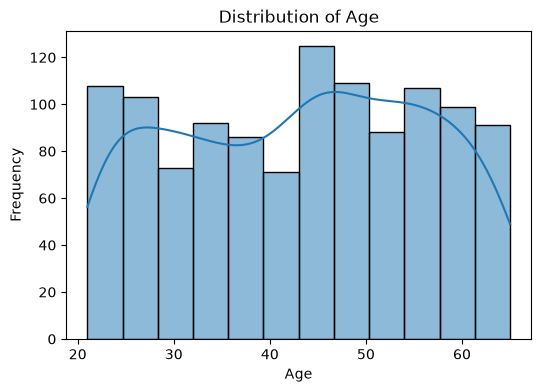

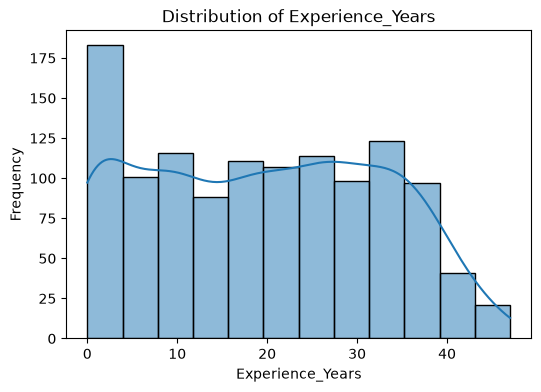

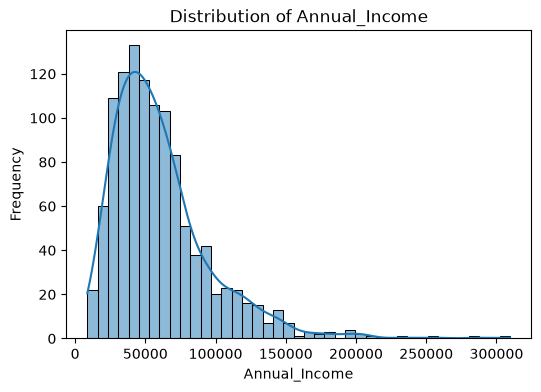

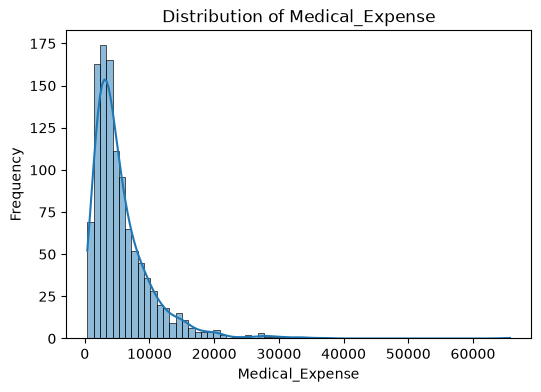

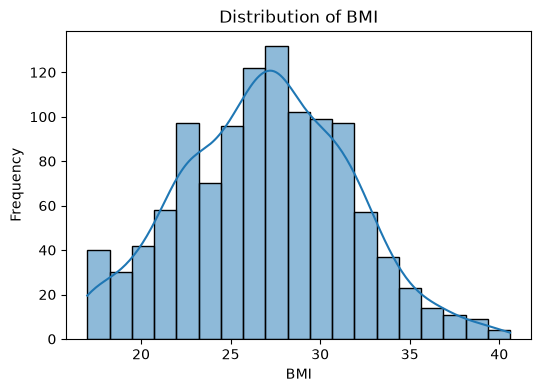

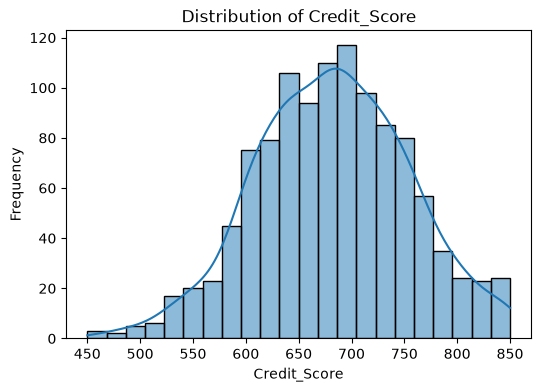

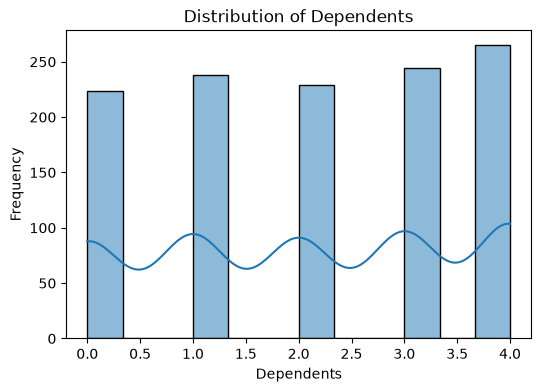

In [24]:
num_cols = ['Age', 'Experience_Years', 'Annual_Income',
            'Medical_Expense', 'BMI', 'Credit_Score', 'Dependents']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

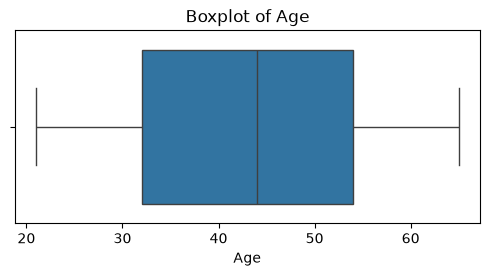

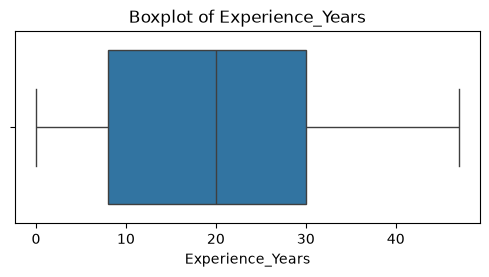

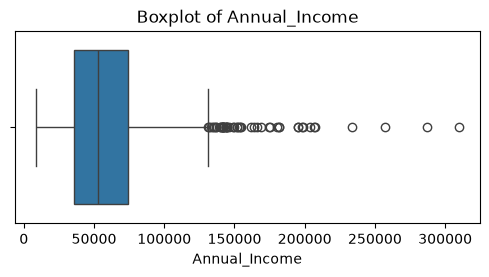

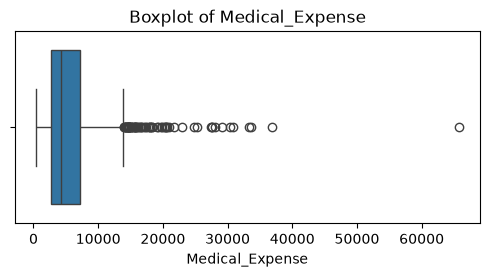

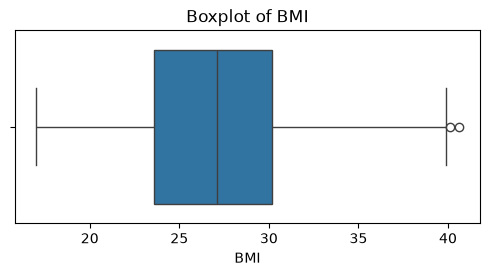

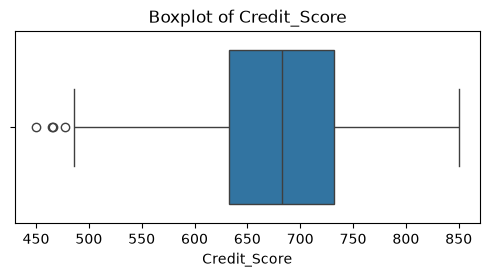

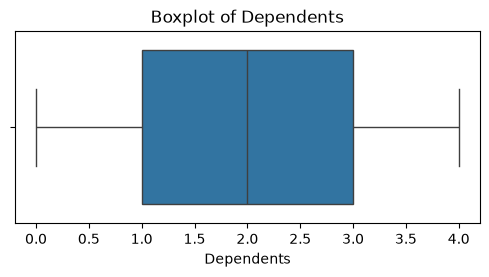

In [25]:
for col in num_cols:
    plt.figure(figsize=(6,2.5))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [26]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(
    df.drop(columns=['Insurance']),df['Insurance'],test_size=0.2,random_state=42
)
# print(x_train,x_test,y_train,y_test)

In [27]:
# first i will Make Pipeline For Skewed Data [Annual Income and Medical Expense]
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler
skew_num_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='median')),
    ('transformer',FunctionTransformer(np.log1p)),
    ('Standard_scaling',StandardScaler())
])

In [28]:
#now creating Pipeline for the Simple Numerical Columns 

num_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='mean')),
    ('Standard_scaling',StandardScaler())
])

In [29]:
# Now Creating Pipeline for Columns Where binning Applied 
from sklearn.preprocessing import KBinsDiscretizer
binning_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='mean')),
    ('binning',KBinsDiscretizer(n_bins=5,strategy='uniform',encode='ordinal'))
])


In [47]:
# now creating pipeline for columns where binirization needed 
from sklearn.preprocessing import Binarizer
binirization_pipeline=Pipeline([
    
    ('imputer',SimpleImputer(strategy='median')),
    ('binirization',Binarizer(threshold=27.1))
])

In [48]:
from sklearn.preprocessing import OneHotEncoder
nominal_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('nominal_ohe',OneHotEncoder())
    
]) # i will apply this on GenderEmployementType,CitySmoking_status

In [49]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_pipeline=Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('ordinal_encoder',OrdinalEncoder(categories=[
        [ 'High School','Bachelor','Master','PhD' ],
        ['Poor','Average','Good','Excellent']
                                                  ]))
])

In [50]:
skewed_num_cols = ['Annual_Income', 'Medical_Expense']

simple_num_cols = ['Experience_Years', 'Credit_Score', 'Dependents']

age_bin_cols = ['Age']

bmi_bin_cols = ['BMI']

nominal_cols = ['Gender', 'Employment_Type', 'City', 'Smoking_Status']

ordinal_cols = ['Education', 'Health_Status']

In [51]:
from sklearn.compose import ColumnTransformer

preprocessing=ColumnTransformer([
    ('Skewed_numerical_data',skew_num_pipeline,skewed_num_cols),
    ('numerical_data',num_pipeline,simple_num_cols),
    ('binning_data',binning_pipeline,age_bin_cols),
    ('binirization_data',binirization_pipeline,bmi_bin_cols),
    ('nominal_data',nominal_pipeline,nominal_cols),
    ('ordinal_data',ordinal_pipeline,ordinal_cols)
])

In [52]:
from sklearn.linear_model import LogisticRegression
model=Pipeline([
    ('preprocess',preprocessing),
    ('lr',LogisticRegression())
])

In [53]:
model.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('lr', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](13,)","['Age','Gender','Education',...,'Dependents','Smoking_Status', 'Health_Status']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Skewed_numerical_data', ...), ('numerical_data', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By

In [54]:
y_pred=model.predict(x_train)

In [58]:
from sklearn.metrics import accuracy_score

accuracyScore=accuracy_score(y_train,y_pred)

print(f'model is {accuracyScore*100} % Accurate ')

model is 56.56250000000001 % Accurate 


In [65]:
from sklearn.model_selection import GridSearchCV
param_grid = {

    # Logistic Regression
    'lr__C': [0.01, 0.1, 1, 10, 100],

   
    'preprocess__Skewed_numerical_data__imputer__strategy':
        ['mean', 'median'],

    'preprocess__numerical_data__imputer__strategy':
        ['mean', 'median'],


    'preprocess__binning_data__imputer__strategy':
        ['mean', 'median'],

    
    'preprocess__binirization_data__imputer__strategy':
        ['mean', 'median'],

    
    'preprocess__nominal_data__imputer__strategy':
        ['most_frequent', 'constant'],

   
    'preprocess__ordinal_data__imputer__strategy':
        ['most_frequent', 'constant']
}

In [66]:
grid_search = GridSearchCV(
    model,
    param_grid,
    cv=5
)

In [67]:
grid_search.fit(x_train, y_train)

c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py:489: FitFailedWarning: 
800 fits failed out of a total of 1600.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
800 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\User\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\base.py", line 1403, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\User\AppDat

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...egression())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'lr__C': [0.01, 0.1, ...], 'preprocess__Skewed_num...data__imputer__strategy': ['mean', 'median'], 'preprocess__binirization_data__imputer__strategy': ['mean', 'median'], 'preprocess__binning_data__imputer__strategy': ['mean', 'median'], ...}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`

In [68]:
grid_search.best_params_

{'lr__C': 0.01,
 'preprocess__Skewed_numerical_data__imputer__strategy': 'median',
 'preprocess__binirization_data__imputer__strategy': 'median',
 'preprocess__binning_data__imputer__strategy': 'mean',
 'preprocess__nominal_data__imputer__strategy': 'constant',
 'preprocess__numerical_data__imputer__strategy': 'mean',
 'preprocess__ordinal_data__imputer__strategy': 'most_frequent'}

In [70]:
grid_search.best_score_

np.float64(0.5572916666666667)

In [79]:
grid_predictions = grid_search.predict(x_test)
grid_accuracy = accuracy_score(y_test, grid_predictions)

print(f"GridSearch Test Accuracy: {grid_accuracy * 100:.2f}%")

GridSearch Test Accuracy: 57.50%


In [77]:
best_model = grid_search.best_estimator_
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix")
print(confusion_matrix(y_test, grid_predictions))

print("\nClassification Report ")
print(classification_report(y_test, grid_predictions))

Confusion Matrix
[[79 55]
 [47 59]]

Classification Report 
              precision    recall  f1-score   support

          No       0.63      0.59      0.61       134
         Yes       0.52      0.56      0.54       106

    accuracy                           0.57       240
   macro avg       0.57      0.57      0.57       240
weighted avg       0.58      0.57      0.58       240



In [80]:
import pickle

with open('../models/customer_insurance_gridsearch_model.pkl', 'wb') as file:
    pickle.dump(best_model, file)